In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('cleaned_customer_sales.csv')
df.head()

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,Male,52,Kolkata,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,Male,51,Kolkata,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,India
2,CUST3754,Brittney Martinez,Female,62,Hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,Female,40,Hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,India
4,CUST5683,Matthew Carroll,Female,41,Chennai,2024-04-05,2024-12-15,24268.0,8.0,denise84@example.org,2665569480,India


In [4]:
df.dtypes

Customer_ID            object
Name                   object
Gender                 object
Age                     int64
City                   object
Signup_Date            object
Last_Purchase_Date     object
Purchase_Amount       float64
Feedback_Score        float64
Email                  object
Phone_Number            int64
Country                object
dtype: object

In [5]:
# changing date columns to datetime
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'])
df['Last_Purchase_Date'] = pd.to_datetime(df['Last_Purchase_Date'])

In [6]:
df.dtypes

Customer_ID                   object
Name                          object
Gender                        object
Age                            int64
City                          object
Signup_Date           datetime64[ns]
Last_Purchase_Date    datetime64[ns]
Purchase_Amount              float64
Feedback_Score               float64
Email                         object
Phone_Number                   int64
Country                       object
dtype: object

# Univariate Analysis

In [7]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Age,8989.0,43.418845,3.0,32.0,43.0,55.0,69.0,14.205506
Signup_Date,8989,2023-04-12 06:36:29.075536640,2020-10-08 00:00:00,2022-01-17 00:00:00,2023-04-05 00:00:00,2024-07-12 00:00:00,2025-10-08 00:00:00,NaN
Last_Purchase_Date,8989,2025-04-08 11:24:02.162643200,2024-10-08 00:00:00,2025-01-07 00:00:00,2025-04-10 00:00:00,2025-07-08 00:00:00,2025-10-08 00:00:00,NaN
Purchase_Amount,8989.0,24654.581266,-500.0,13831.0,24268.0,35660.0,49992.0,13622.63894
Feedback_Score,8989.0,5.13828,1.0,2.0,5.0,8.0,10.0,2.909729
Phone_Number,8989.0,4984198063.633997,920899.0,2452540550.0,4999279242.0,7511244565.0,9994402181.0,2901468071.334356


In [8]:
# summary statistics for numerical column
numeric_cols = ['Age', 'Purchase_Amount', 'Feedback_Score']

summary = df[numeric_cols].describe().T
summary['median'] = df[numeric_cols].median()
summary['IQR'] = summary['75%'] - summary['25%']
summary['skewness'] = df[numeric_cols].skew()
print("Numeric Summary Statistics:\n")
summary


Numeric Summary Statistics:



,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
Age,8989.0,43.418845,14.205506,3.0,32.0,43.0,55.0,69.0,43.0,23.0,0.007311
Purchase_Amount,8989.0,24654.581266,13622.638940,-500.0,13831.0,24268.0,35660.0,49992.0,24268.0,21829.0,0.050347
Feedback_Score,8989.0,5.138280,2.909729,1.0,2.0,5.0,8.0,10.0,5.0,6.0,0.188718


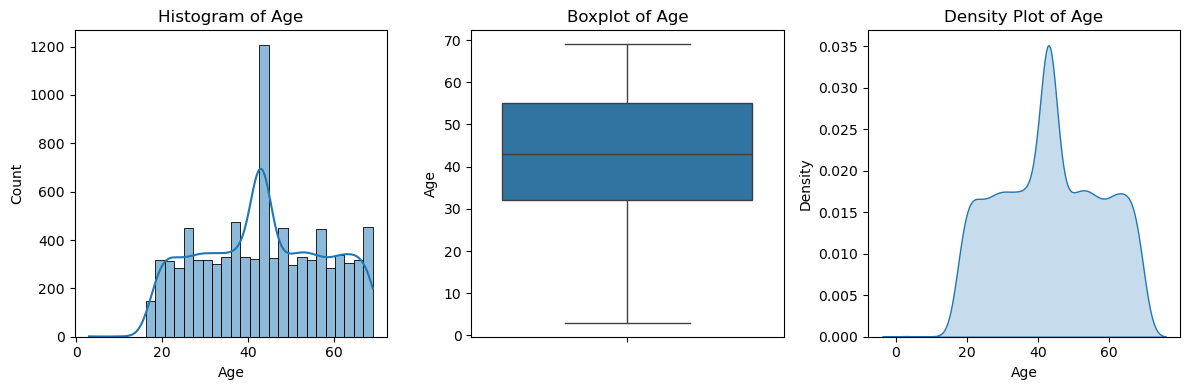

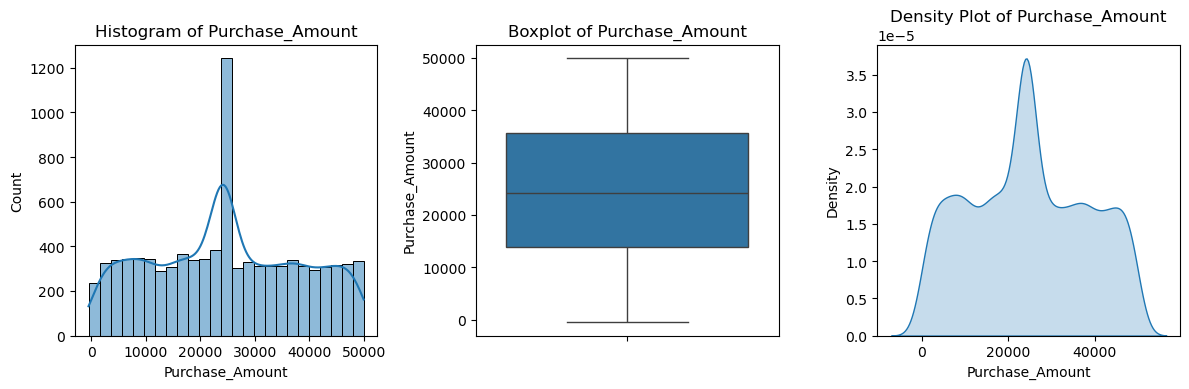

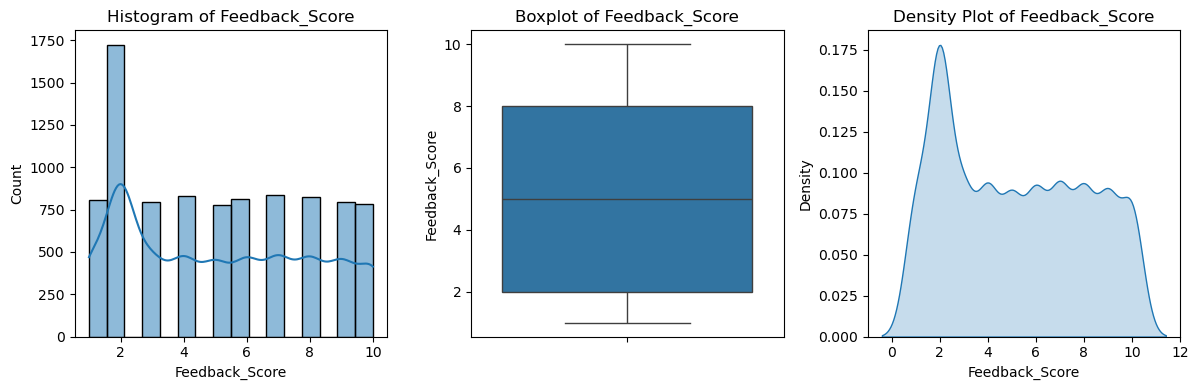

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
# histogram, boxplot, density plot for numerical columns
for col in numeric_cols:
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')

    plt.subplot(1,3,2)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

    plt.subplot(1,3,3)
    sns.kdeplot(df[col], fill=True)
    plt.title(f'Density Plot of {col}')

    plt.tight_layout()
    plt.show()



 Frequency counts for Gender:
 Gender
Male      4958
Female    4031
Name: count, dtype: int64


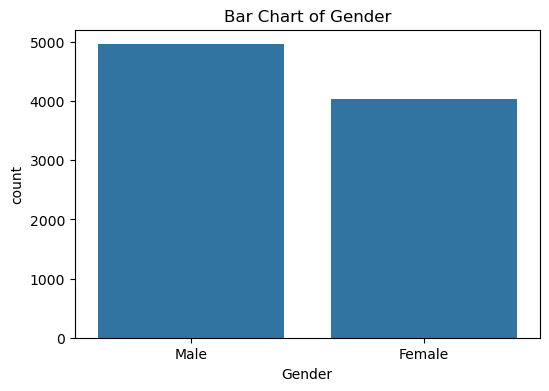


 Frequency counts for City:
 City
Kolkata      2255
Mumbai       1358
Chennai      1354
Delhi        1350
Hyderabad    1337
Bangalore    1335
Name: count, dtype: int64


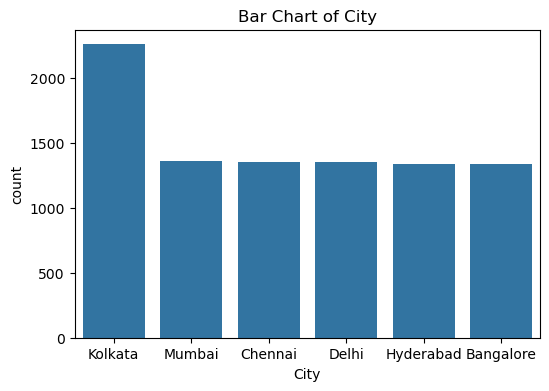

In [10]:
# Frequency count for categorical columns
cat_cols = ['Gender', 'City']

for index, col in enumerate(cat_cols):
    print(f"\n Frequency counts for {col}:\n", df[col].value_counts())
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Bar Chart of {col}')
    plt.show()


 Date Range for Signup_Date: 2020-10-08 00:00:00 to 2025-10-08 00:00:00
Time span: 1826 days

 Date Range for Last_Purchase_Date: 2024-10-08 00:00:00 to 2025-10-08 00:00:00
Time span: 365 days


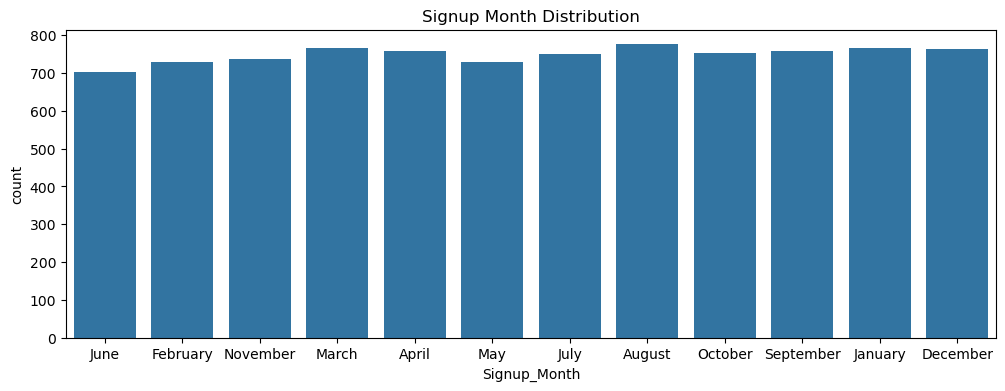

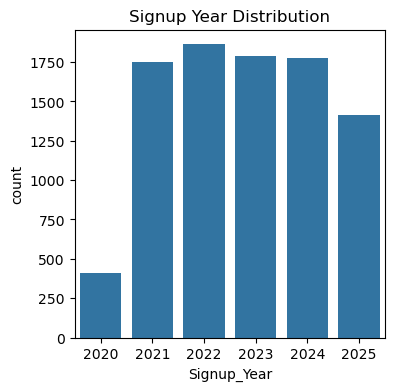

In [11]:

date_cols = ['Signup_Date', 'Last_Purchase_Date']

for col in date_cols:
    print(f"\n Date Range for {col}: {df[col].min()} to {df[col].max()}")
    print(f"Time span: {(df[col].max() - df[col].min()).days} days")

# Month distribution
plt.figure(figsize = (12,4))
df['Signup_Month'] = df['Signup_Date'].dt.month_name()
sns.countplot(x='Signup_Month', data=df)
plt.title('Signup Month Distribution')
plt.show()

# Year distribution
plt.figure(figsize = (4,4))
df['Signup_Year'] = df['Signup_Date'].dt.year
sns.countplot(x='Signup_Year', data=df)
plt.title('Signup Year Distribution')
plt.show()

In [12]:
def time_granularity(series):
    diffs = series.sort_values().diff().dropna().dt.days
    return diffs.describe()

In [13]:
time_granularity(df['Last_Purchase_Date'])

count    8988.000000
mean        0.040610
std         0.197395
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: Last_Purchase_Date, dtype: float64

In [14]:
df['Last_Purchase_Date'].sort_values().diff().value_counts()

Last_Purchase_Date
0 days    8623
1 days     365
Name: count, dtype: int64

In [15]:
time_granularity(df['Signup_Date'])

count    8988.000000
mean        0.203160
std         0.405952
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         3.000000
Name: Signup_Date, dtype: float64

In [16]:
df['Signup_Date'].sort_values().diff().value_counts()

Signup_Date
0 days    7174
1 days    1803
2 days      10
3 days       1
Name: count, dtype: int64

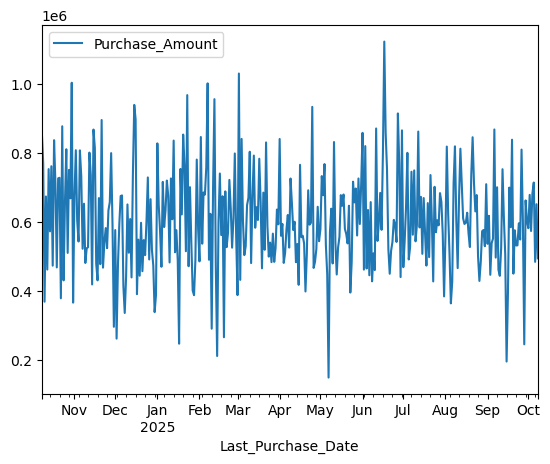

In [17]:
df.groupby('Last_Purchase_Date')[['Purchase_Amount']].sum().plot()
plt.show()

/var/folders/7p/9fzd376x7ll_q2md42x9_71c0000gn/T/ipykernel_9762/4033751749.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  result.plot().show()


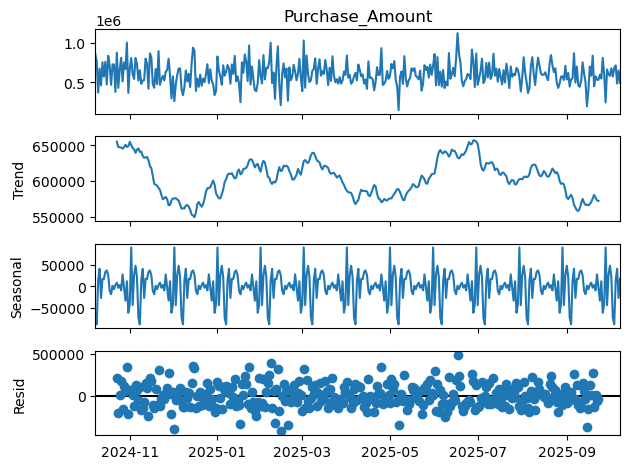

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

df_daily = df.groupby('Last_Purchase_Date')['Purchase_Amount'].sum()
result = seasonal_decompose(df_daily, model='additive', period=30)
result.plot().show()

In [19]:
df["day"] = df["Last_Purchase_Date"].dt.day
df["month"] = df["Last_Purchase_Date"].dt.month
heatmap_data = df.pivot_table(
    index="day",
    columns="month",
    values="Purchase_Amount",
    aggfunc="mean"
)
heatmap_data

month,1,2,3,4,5,6,7,8,9,10,11,12
day,,,,,,,,,,,,
1,27623.000000,23183.428571,20476.210526,24040.942857,25208.043478,26036.000000,27651.176471,22387.840000,22403.583333,22421.076923,21131.968750,25107.739130
2,27093.958333,31375.888889,25778.175000,25500.772727,24462.366667,22044.904762,23722.000000,25609.718750,25783.541667,32357.523810,27891.103448,21919.083333
3,24976.913043,26900.600000,22799.947368,25886.347826,26090.346154,24140.411765,25750.800000,26045.583333,24883.500000,27373.904762,22455.481481,22642.904762
4,27715.176471,25429.555556,31171.592593,20973.086957,24798.419355,23306.250000,22257.666667,28244.055556,29982.555556,26289.384615,25923.428571,28289.380952
5,26559.074074,27212.480000,22324.666667,26898.684211,26781.300000,23548.740741,23446.047619,22820.125000,25133.590909,24663.758621,26948.266667,25043.851852
6,21716.259259,26192.172414,24042.761905,23163.960000,21411.190476,23506.315789,22014.125000,20409.952381,24140.194444,26972.222222,26213.321429,28244.583333
7,31701.800000,27850.194444,27900.263158,23009.925926,13645.909091,25327.692308,24882.666667,27436.961538,23703.523810,27182.833333,20937.040000,24439.470588
8,28836.520000,20482.208333,27057.916667,30989.470588,21959.730769,25240.470588,26862.285714,26455.548387,24191.379310,25110.648148,26157.760000,21080.562500
9,23323.896552,23135.814815,21646.870968,25960.964286,22839.357143,26845.368421,26802.392857,28789.047619,33051.928571,24082.406250,20965.217391,22114.000000


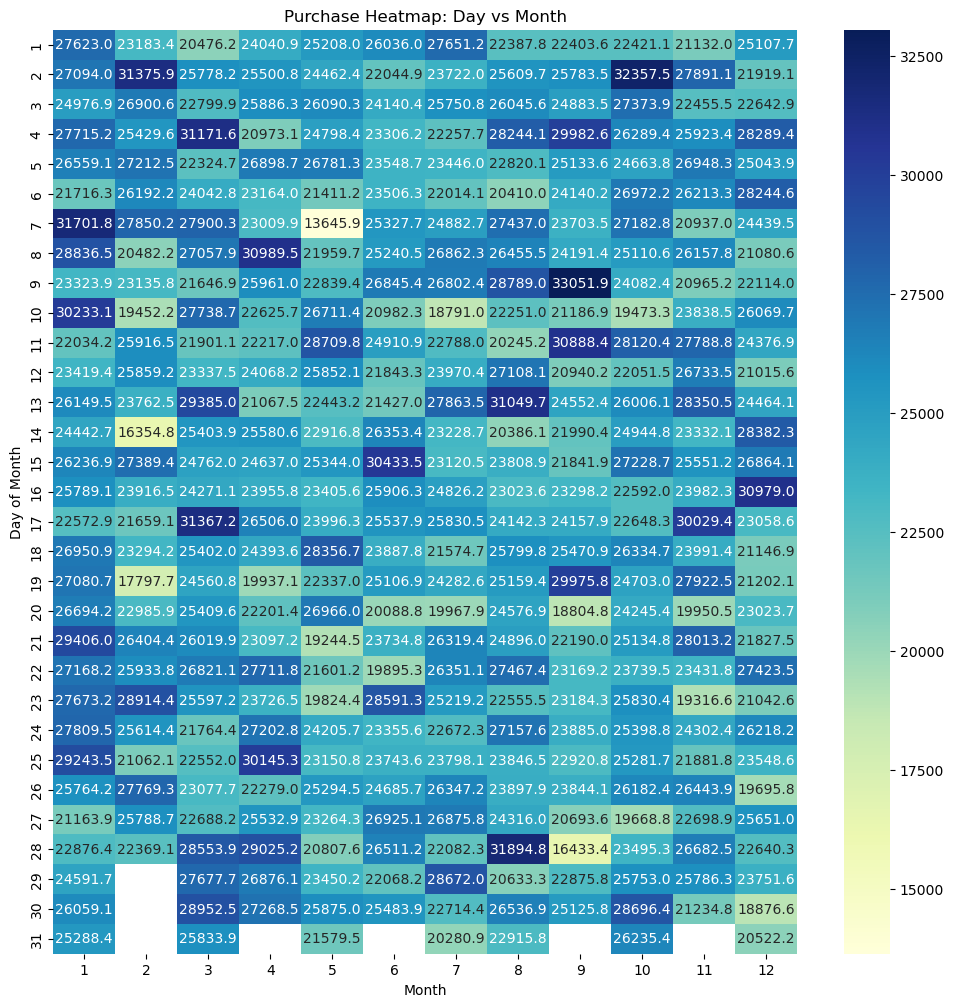

In [20]:

# Plot heatmap
plt.figure(figsize=(12,12))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt=".1f")
plt.xlabel("Month")
plt.ylabel("Day of Month")
plt.title("Purchase Heatmap: Day vs Month")
plt.show()


In [21]:
text_df = pd.read_csv('fake_or_real_news.csv')
text_df 

,title,text,label
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
...,...,...,...
1995,5 Reasons Cruz Announced His Candidacy Early,Texas Sen. Ted Cruz has apparently had enough ...,REAL
1996,“Beware of the Shadow Government”: Ron Paul Ad...,\nThis article was written and originally publ...,FAKE
1997,The GOP farce plods along: Why last night’s in...,"Of course, all the contenders genuflected at t...",REAL
1998,"Fuming over Ryan, some conservative voices tur...",Rep. Mark Meadows (R-N.C.) has been able to co...,REAL


In [22]:
import re
# Text preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

text_df["clean_text"] = text_df["text"].apply(clean_text)

In [23]:

text_df["tokens"] = text_df["clean_text"].apply(lambda x: x.split())

In [24]:

text_df["token_count"] = text_df["tokens"].apply(len)
text_df

,title,text,label,clean_text,tokens,token_count
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE,daniel greenfield a shillman journalism fellow...,"[daniel, greenfield, a, shillman, journalism, ...",1295
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE,google pinterest digg linkedin reddit stumbleu...,"[google, pinterest, digg, linkedin, reddit, st...",437
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL,us secretary of state john f kerry said monday...,"[us, secretary, of, state, john, f, kerry, sai...",429
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE,kaydee king kaydeeking november the lesson ...,"[kaydee, king, kaydeeking, november, the, less...",377
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL,its primary day in new york and frontrunners h...,"[its, primary, day, in, new, york, and, frontr...",313
...,...,...,...,...,...,...
1995,5 Reasons Cruz Announced His Candidacy Early,Texas Sen. Ted Cruz has apparently had enough ...,REAL,texas sen ted cruz has apparently had enough o...,"[texas, sen, ted, cruz, has, apparently, had, ...",956
1996,“Beware of the Shadow Government”: Ron Paul Ad...,\nThis article was written and originally publ...,FAKE,\nthis article was written and originally publ...,"[this, article, was, written, and, originally,...",622
1997,The GOP farce plods along: Why last night’s in...,"Of course, all the contenders genuflected at t...",REAL,of course all the contenders genuflected at th...,"[of, course, all, the, contenders, genuflected...",1197
1998,"Fuming over Ryan, some conservative voices tur...",Rep. Mark Meadows (R-N.C.) has been able to co...,REAL,rep mark meadows rnc has been able to count on...,"[rep, mark, meadows, rnc, has, been, able, to,...",1320


Token Count Summary
count     2000.000000
mean       770.661500
std        848.234393
min          0.000000
25%        291.000000
50%        589.500000
75%       1011.250000
max      14672.000000
Name: token_count, dtype: float64


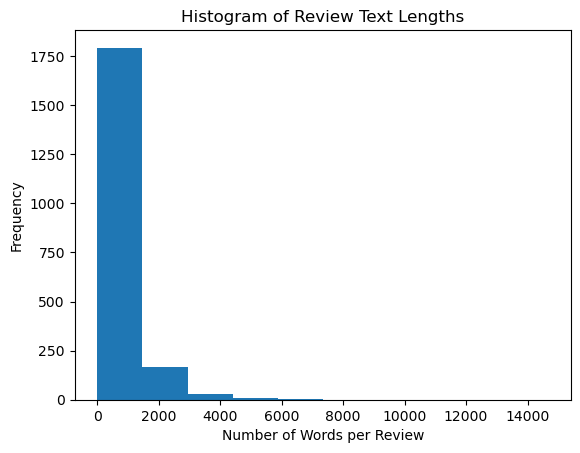

In [25]:
print("Token Count Summary")
print(text_df["token_count"].describe())

# Histogram of text lengths
plt.figure()
plt.hist(text_df["token_count"])
plt.xlabel("Number of Words per Review")
plt.ylabel("Frequency")
plt.title("Histogram of Review Text Lengths")
plt.show()

In [27]:
# most common words 
from collections import Counter
all_tokens = [token for tokens in text_df["tokens"] for token in tokens]
word_freq = Counter(all_tokens)

top_words = word_freq.most_common(10)
top_words_df = pd.DataFrame(top_words, columns=["word", "count"])

print("\nTop 10 Most Common Words")
print(top_words_df)


Top 10 Most Common Words
   word  count
0   the  92877
1    to  44549
2    of  41486
3   and  38482
4     a  34212
5    in  31563
6  that  22202
7    is  17275
8   for  14476
9    on  13013



Top 10 Most Common Words
        word  count
0      trump   6447
1    clinton   4558
2      state   2625
3  president   2528
4   campaign   2501
5     states   2152
6    hillary   2106
7       time   2073
8      obama   2060
9   election   1733


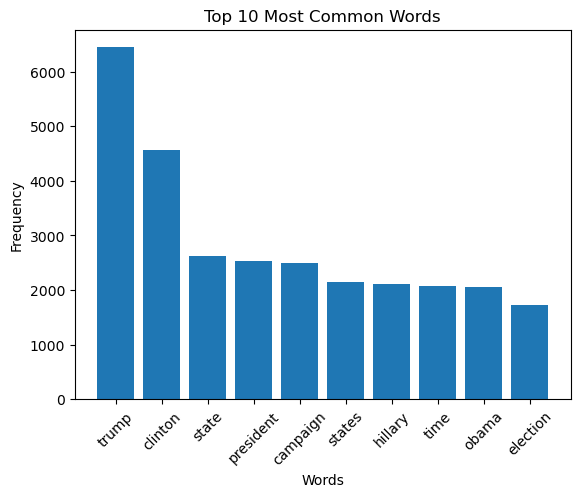

In [28]:
# after removing stopwords
from nltk.corpus import stopwords
stopword = set(stopwords.words())
all_tokens = [token for token in all_tokens if token not in stopword]
word_freq = Counter(all_tokens)

top_words = word_freq.most_common(10)
top_words_df = pd.DataFrame(top_words, columns=["word", "count"])

print("\nTop 10 Most Common Words")
print(top_words_df)

plt.figure()
plt.bar(top_words_df["word"], top_words_df["count"])
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 10 Most Common Words")
plt.xticks(rotation=45)
plt.show()

# Bivariate Analysis

In [29]:
weather_df = pd.read_csv('weather.csv')
weather_df

,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
0,14.110847,18.18125,80.5833,10.749882,4.805490,985
1,14.902598,17.68695,69.6087,16.652113,7.443949,801
2,8.050924,9.47025,43.7273,16.636703,7.437060,1349
3,8.200000,10.60610,59.0435,10.739832,4.800998,1562
4,9.305237,11.46350,43.6957,12.522300,5.597810,1600
...,...,...,...,...,...,...
726,10.420847,11.33210,65.2917,23.458911,10.486773,2114
727,10.386653,12.75230,59.0000,10.416557,4.656485,3095
728,10.386653,12.12000,75.2917,8.333661,3.725374,1341
729,10.489153,11.58500,48.3333,23.500518,10.505372,1796


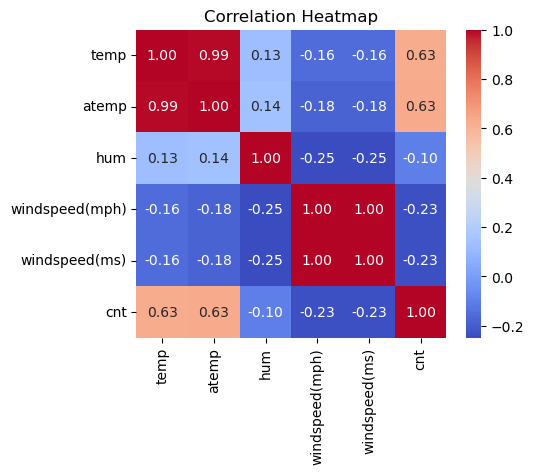

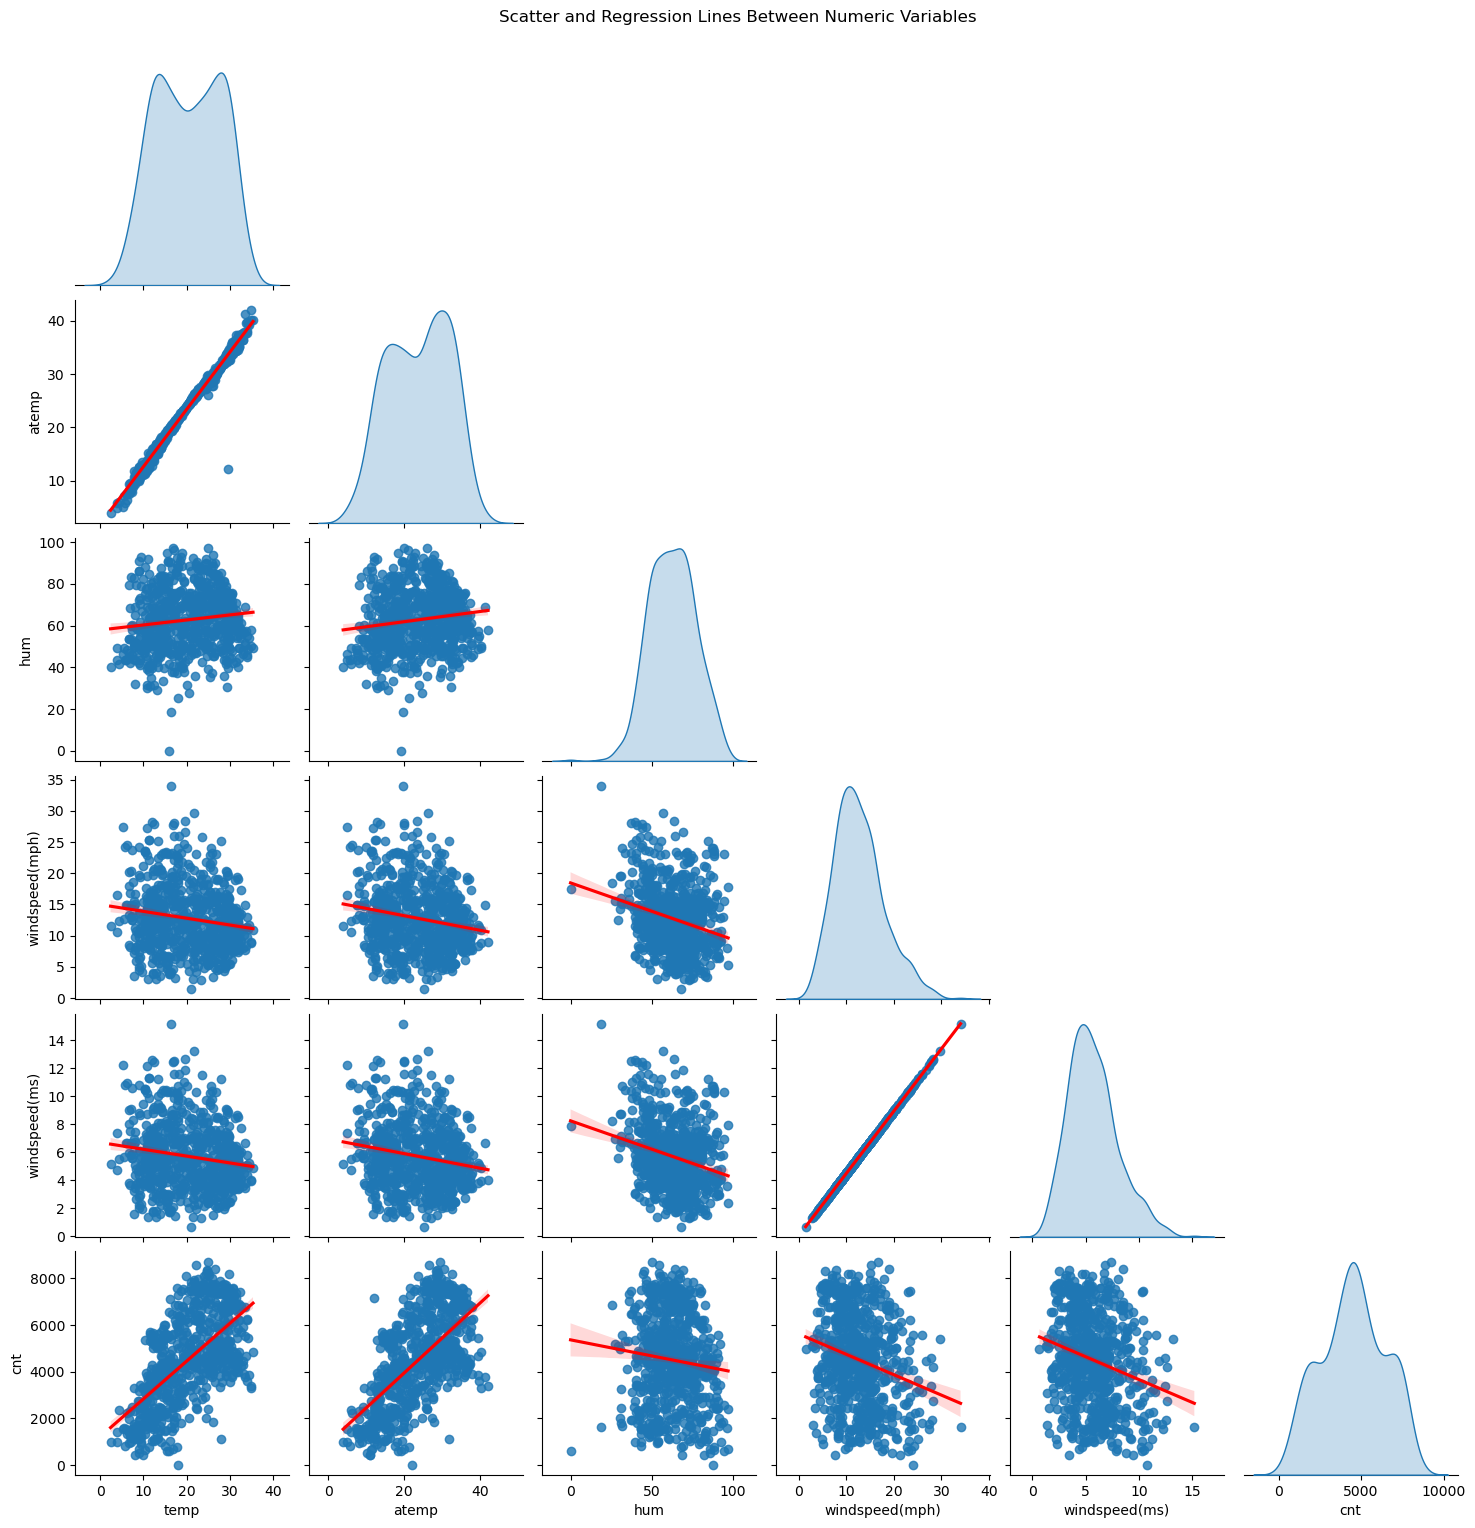

In [30]:

corr = weather_df.corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Pairwise scatter plots + regression line
sns.pairplot(weather_df, kind='reg', diag_kind='kde', corner=True, plot_kws={'line_kws':{'color':'red'}})
plt.suptitle('Scatter and Regression Lines Between Numeric Variables', y=1.02)
plt.show()


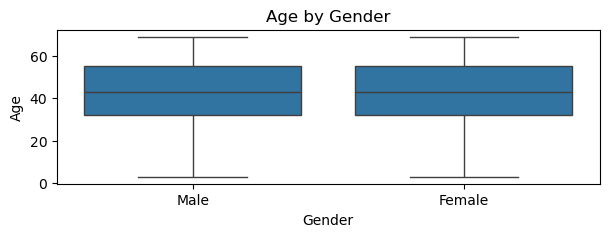


📊 Group Mean and Median of Age by Gender:
             mean  median  count
Gender                          
Female  43.445795    43.0   4031
Male    43.396934    43.0   4958


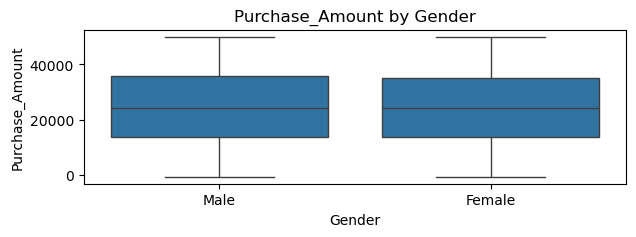


📊 Group Mean and Median of Purchase_Amount by Gender:
                mean   median  count
Gender                              
Female  24430.358968  24268.0   4031
Male    24836.880597  24268.0   4958


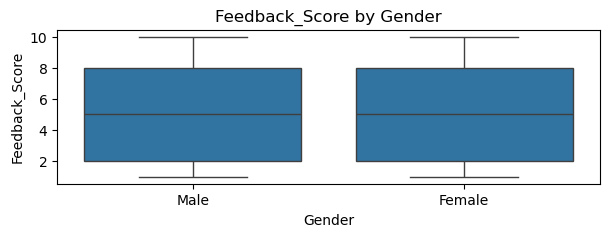


📊 Group Mean and Median of Feedback_Score by Gender:
            mean  median  count
Gender                         
Female  5.125279     5.0   4031
Male    5.148850     5.0   4958


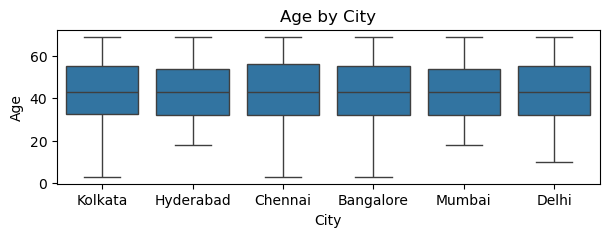


📊 Group Mean and Median of Age by City:
                mean  median  count
City                               
Bangalore  43.310112    43.0   1335
Chennai    43.881832    43.0   1354
Delhi      43.429630    43.0   1350
Hyderabad  43.649963    43.0   1337
Kolkata    43.445233    43.0   2255
Mumbai     42.782032    43.0   1358


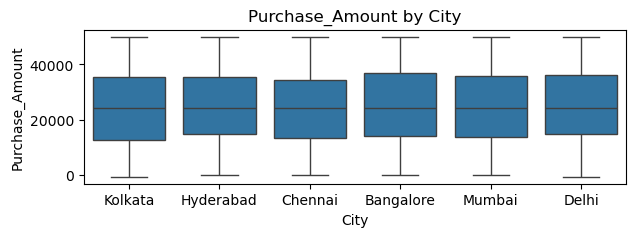


📊 Group Mean and Median of Purchase_Amount by City:
                   mean   median  count
City                                   
Bangalore  25189.216479  24268.0   1335
Chennai    23969.135894  24268.0   1354
Delhi      25101.271111  24268.0   1350
Hyderabad  24790.829469  24268.0   1337
Kolkata    24372.164523  24268.0   2255
Mumbai     24703.189249  24268.0   1358


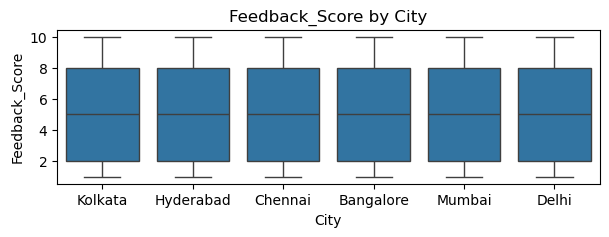


📊 Group Mean and Median of Feedback_Score by City:
               mean  median  count
City                              
Bangalore  5.259925     5.0   1335
Chennai    5.076071     5.0   1354
Delhi      5.106667     5.0   1350
Hyderabad  5.211668     5.0   1337
Kolkata    5.076275     5.0   2255
Mumbai     5.142857     5.0   1358


In [31]:
cat_cols = ['Gender', 'City']

for cat in cat_cols:
    for num in numeric_cols:
        plt.figure(figsize=(7,2))
        sns.boxplot(x=cat, y=num, data=df)
        plt.title(f'{num} by {cat}')
        plt.show()

        print(f"\n📊 Group Mean and Median of {num} by {cat}:")
        print(df.groupby(cat)[num].agg(['mean','median','count']))


In [32]:
from scipy import stats
anova_res = stats.f_oneway(*[group["Feedback_Score"].values for name, group in df.groupby("City")])
print("📈 ANOVA Test for Feedback_Score across Cities:")
print("F-statistic:", round(anova_res.statistic, 3), ", p-value:", round(anova_res.pvalue, 3))

📈 ANOVA Test for Feedback_Score across Cities:
F-statistic: 0.998 , p-value: 0.417



 Contingency Table (Gender vs City):
 City    Bangalore  Chennai  Delhi  Hyderabad  Kolkata  Mumbai
Gender                                                       
Female        602      620    599        625      998     587
Male          733      734    751        712     1257     771


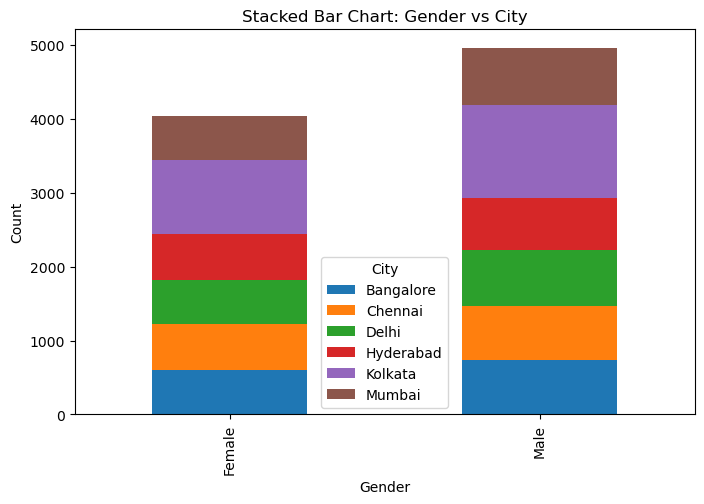


Chi-Square Test Results:
Chi2 = 4.355, p-value = 0.500, Degrees of Freedom = 5
👉 No significant relationship (fail to reject null hypothesis)


In [33]:
contingency = pd.crosstab(df['Gender'], df['City'])
print("\n Contingency Table (Gender vs City):\n", contingency)

# Stacked Bar Chart
contingency.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title('Stacked Bar Chart: Gender vs City')
plt.ylabel('Count')
plt.show()

# Chi-Square Test of Independence
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print("\nChi-Square Test Results:")
print(f"Chi2 = {chi2:.3f}, p-value = {p:.3f}, Degrees of Freedom = {dof}")

if p < 0.05:
    print("👉 Significant relationship (reject null hypothesis)")
else:
    print("👉 No significant relationship (fail to reject null hypothesis)")


In [34]:
sales_df = pd.read_csv('daily_sales_data.csv')
sales_df['date'] = pd.to_datetime(sales_df['date'])

In [35]:
sales_df

,date,sales
0,2024-01-02,2888
1,2024-01-03,2982
2,2024-01-04,1000
3,2024-01-06,2663
4,2024-01-07,1579
...,...,...
95,2024-04-25,1459
96,2024-04-26,2755
97,2024-04-27,2169
98,2024-04-28,2786


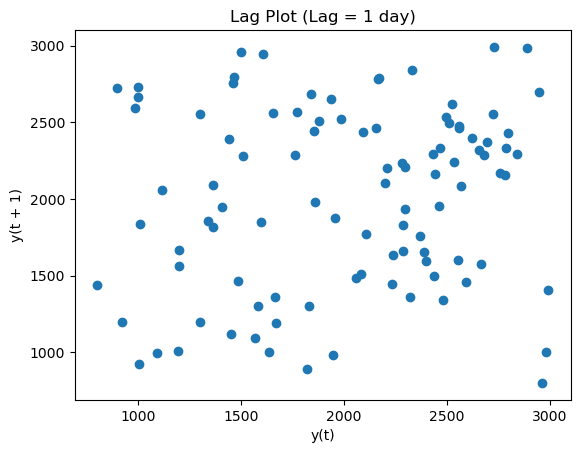

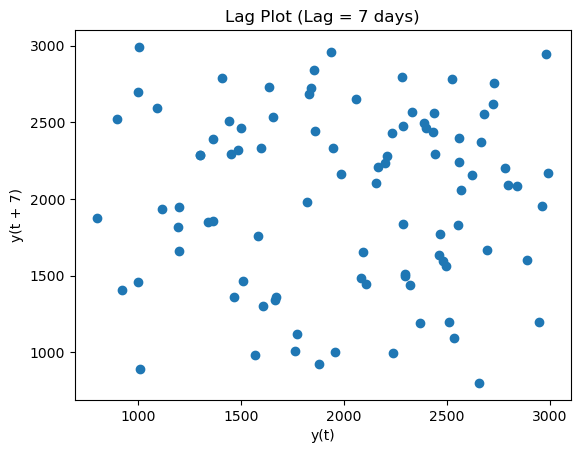

In [36]:
from pandas.plotting import lag_plot

plt.figure()
lag_plot(sales_df["sales"], lag=1)
plt.title("Lag Plot (Lag = 1 day)")
plt.show()

plt.figure()
lag_plot(sales_df["sales"], lag=7)
plt.title("Lag Plot (Lag = 7 days)")
plt.show()

<Figure size 640x480 with 0 Axes>

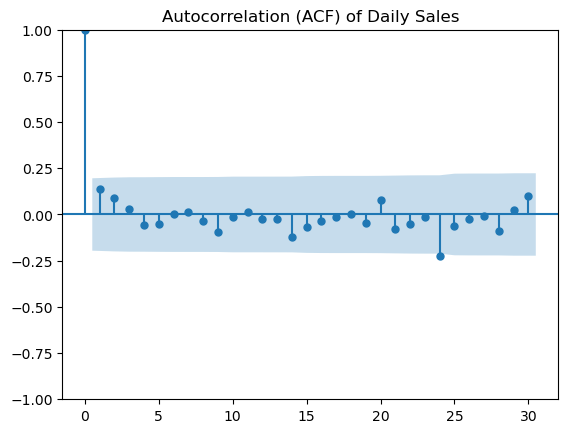

In [37]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure()
plot_acf(sales_df["sales"], lags=30)
plt.title("Autocorrelation (ACF) of Daily Sales")
plt.show()

<Figure size 640x480 with 0 Axes>

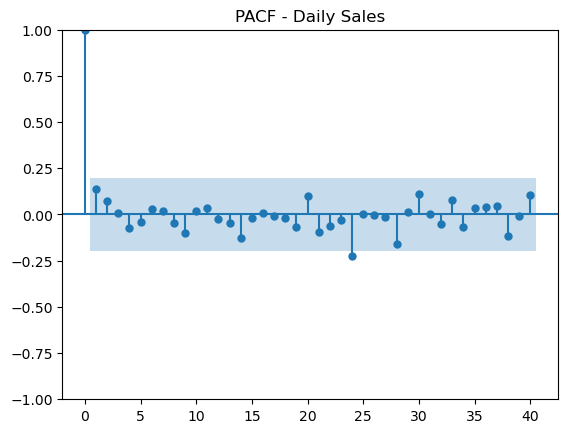

In [38]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure()
plot_pacf(sales_df["sales"], lags=40, method="ywm")
plt.title("PACF - Daily Sales")
plt.show()

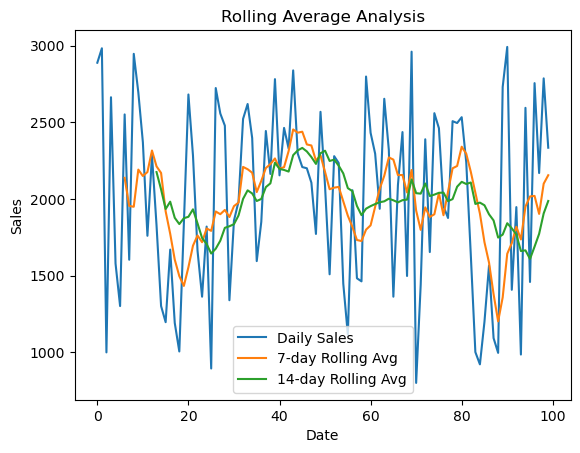

In [39]:
sales_df["rolling_7"] = sales_df["sales"].rolling(window=7).mean()
sales_df["rolling_14"] = sales_df["sales"].rolling(window=14).mean()

plt.figure()
plt.plot(sales_df.index, sales_df["sales"], label="Daily Sales")
plt.plot(sales_df.index, sales_df["rolling_7"], label="7-day Rolling Avg")
plt.plot(sales_df.index, sales_df["rolling_14"], label="14-day Rolling Avg")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Rolling Average Analysis")
plt.legend()
plt.show()


# Multivariate Analysis

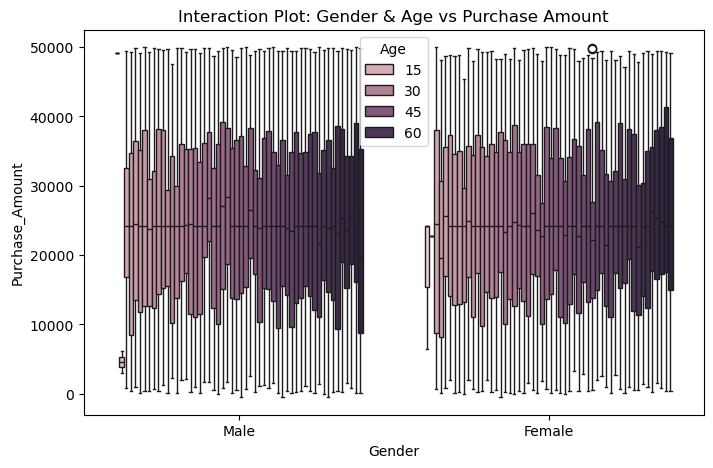

In [40]:
# Example: Age + Gender → Purchase Amount
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='Gender',
    y='Purchase_Amount',
    hue='Age',
    dodge=True
)
plt.title('Interaction Plot: Gender & Age vs Purchase Amount')
plt.show()

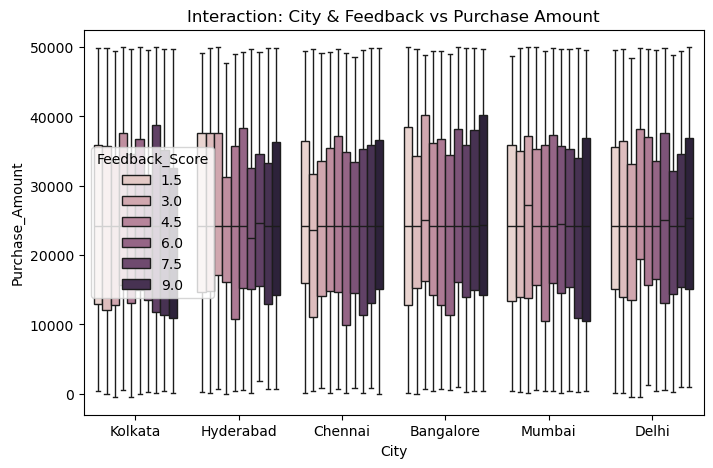

In [41]:
# Another example: City + Feedback → Purchase Amount

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='City',
    y='Purchase_Amount',
    hue='Feedback_Score'
)
plt.title('Interaction: City & Feedback vs Purchase Amount')
plt.show()


In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
X = df[numeric_cols]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

print("Explained Variance Ratio:", pca.explained_variance_ratio_)


Explained Variance Ratio: [0.33732738 0.33268221]


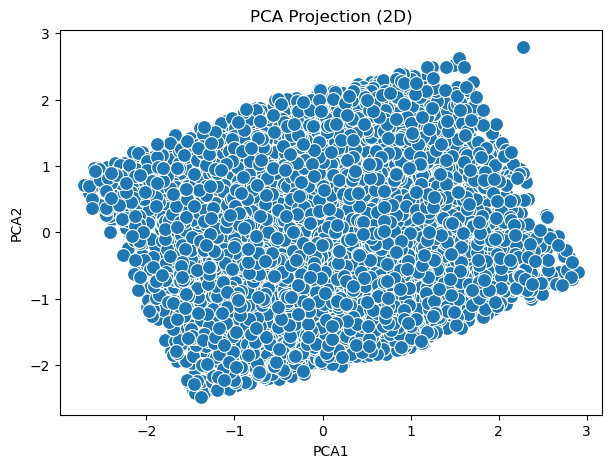

In [43]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    data=df,
    s=100
)
plt.title('PCA Projection (2D)')
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


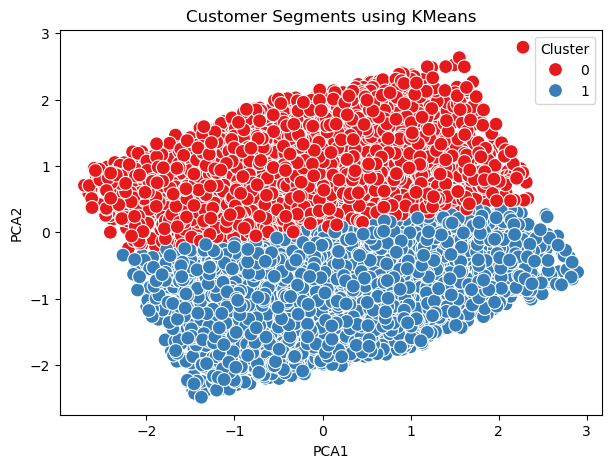

In [46]:
# KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_pca)
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=df,
    palette='Set1',
    s=100
)
plt.title('Customer Segments using KMeans')
plt.show()


In [48]:
df['Cluster'].value_counts()

Cluster
1    4795
0    4194
Name: count, dtype: int64

In [49]:
print(df.groupby('Cluster')[numeric_cols].mean())

               Age  Purchase_Amount  Feedback_Score
Cluster                                            
0        42.567716     36380.199094        5.756319
1        44.163295     14398.639416        4.597706
